In [45]:
import pandas as pan
import numpy as num

In [46]:
df1 = pan.read_csv('/content/penguins.csv')

In [47]:
df1

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,36.7,19.3,193.0,3450.0,FEMALE
4,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...
327,47.2,13.7,214.0,4925.0,FEMALE
328,46.8,14.3,215.0,4850.0,FEMALE
329,50.4,15.7,222.0,5750.0,MALE
330,45.2,14.8,212.0,5200.0,FEMALE


In [48]:
from sklearn.preprocessing import OneHotEncoder

In [49]:
df1 = pan.get_dummies(df1 , columns = ['sex'], drop_first = True )

In [50]:
df1

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex_MALE
0,39.1,18.7,181.0,3750.0,True
1,39.5,17.4,186.0,3800.0,False
2,40.3,18.0,195.0,3250.0,False
3,36.7,19.3,193.0,3450.0,False
4,39.3,20.6,190.0,3650.0,True
...,...,...,...,...,...
327,47.2,13.7,214.0,4925.0,False
328,46.8,14.3,215.0,4850.0,False
329,50.4,15.7,222.0,5750.0,True
330,45.2,14.8,212.0,5200.0,False


In [51]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332 entries, 0 to 331
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   332 non-null    float64
 1   culmen_depth_mm    332 non-null    float64
 2   flipper_length_mm  332 non-null    float64
 3   body_mass_g        332 non-null    float64
 4   sex_MALE           332 non-null    bool   
dtypes: bool(1), float64(4)
memory usage: 10.8 KB


In [52]:
df1.isnull().sum()

,0
culmen_length_mm,0
culmen_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex_MALE,0


In [53]:
from sklearn.preprocessing import StandardScaler

In [54]:
x = df1

In [55]:
scaler = StandardScaler()

In [56]:
scaledX_train = scaler.fit_transform(x)
#scaledX_test = scaler.transform(x)

In [57]:
scaledX_train

array([[-0.90390586,  0.79035987, -1.42534179, -0.56694801,  0.99399394],
       [-0.83043377,  0.12618674, -1.0685765 , -0.50484747, -1.00604235],
       [-0.68348959,  0.43272819, -0.42639899, -1.18795343, -1.00604235],
       ...,
       [ 1.17168063, -0.74234736,  1.50013355,  1.91707363,  0.99399394],
       [ 0.21654349, -1.20215952,  0.78660298,  1.23396768, -1.00604235],
       [ 1.07984052, -0.53798639,  0.85795603,  1.48236985,  0.99399394]])

In [58]:
from sklearn.cluster import KMeans

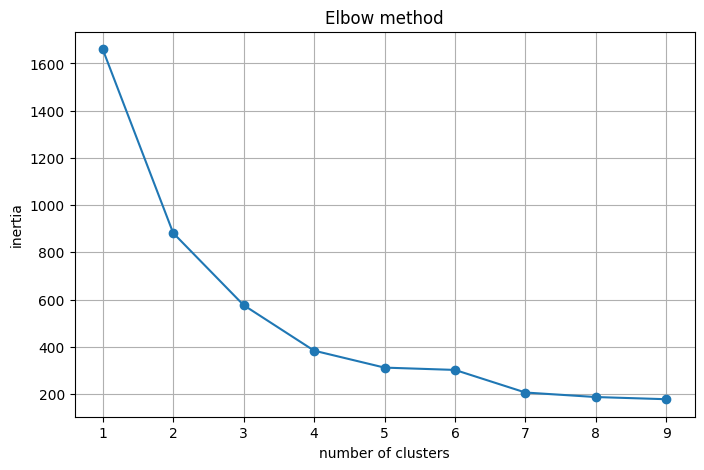

In [59]:
import matplotlib.pyplot as plt

list_for_inertia = []
#k_range = range(1,10)
for kmean in range(1,10):
  means = KMeans(n_clusters = kmean , random_state =42)
  means.fit(scaledX_train)
  list_for_inertia.append(means.inertia_)

plt.figure(figsize = (8,5))
plt.plot(range(1,10) , list_for_inertia , marker = 'o')
plt.title('Elbow method')
plt.xlabel('number of clusters')
plt.ylabel('inertia')
plt.xticks(range(1,10))
plt.grid(True)
plt.show()

In [60]:
list_for_inertia

[1659.9999999999995,
 881.8305702961082,
 576.2691239087538,
 383.4643203353643,
 311.66723081130783,
 301.8612445263756,
 206.1450604785653,
 187.0422108788818,
 177.79321151998153]

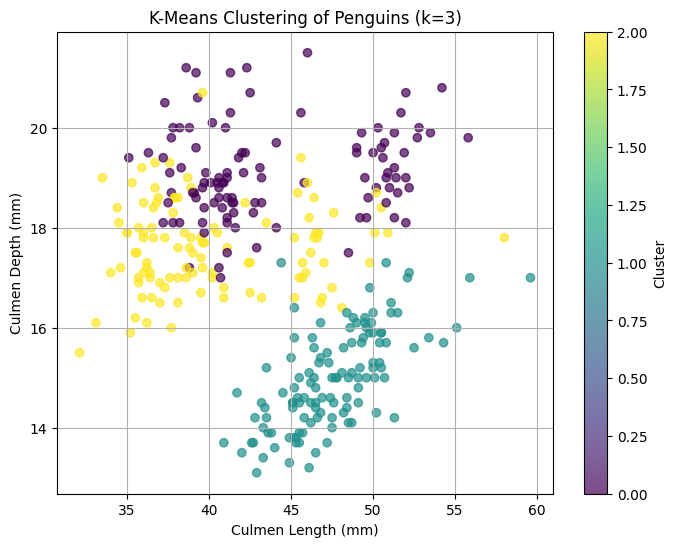

In [61]:
# Choose the optimal number of clusters based on the elbow plot (for example, let's assume k=3)
n_clusters = 3  # Replace with the optimal k you observed

# Run k-means clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(scaledX_train)

# Add cluster labels to the original DataFrame for visualization
df1['cluster'] = cluster_labels

# Visualize the clusters using two features, e.g., 'culmen_length_mm' and 'culmen_depth_mm'
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df1['culmen_length_mm'],
    df1['culmen_depth_mm'],
    c =df1['cluster'],
    cmap='viridis',
    alpha=0.7
)
plt.xlabel('Culmen Length (mm)')
plt.ylabel('Culmen Depth (mm)')
plt.title(f'K-Means Clustering of Penguins (k={n_clusters})')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()


In [62]:
# Add 'label' column with kmeans.labels_
df1['label'] = kmeans.labels_

# Identify numeric features for aggregation (excluding metadata columns)
features = df1.select_dtypes(include=['float64', 'int64']).columns.drop(['cluster', 'label'], errors='ignore')

# Aggregate and display
stat_penguins = df1.groupby('label')[features].mean()
stat_penguins

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
label,,,,
0,43.878302,19.111321,194.764151,4006.603774
1,47.568067,14.996639,217.235294,5092.436975
2,40.217757,17.611215,189.046729,3419.158879
